# Model Building & Analysis

# Optimizing Perishable Inventory to Reduce Retail Food Waste

This notebook focuses on building a predictive model to estimate **weekly sales** for grocery and produce departments (Departments 92 & 95).  

By accurately forecasting sales, retail stores can:

- Optimize inventory levels  
- Reduce overstocking of perishable items  
- Minimize food waste and improve profitability  

I used a **Linear regression & Random Forest Regressor** on historical sales, store characteristics, promotions, and environmental features to predict weekly sales.

In [106]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# importing the cleaned data for deliverable 2
final_df = pd.read_csv(r'C:\Users\user\Desktop\ALTSCHOOL AFRICA\CAPSTONE PROJECT\ECOSHELF PROJECT - ALTSCHOOL CAPSTONE PROJECT\DELIVERABLE 2\cleaned_food_data.xls')
final_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Month,Week,High_Heat
0,1,92,2010-02-05,139884.94,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2,5,0
1,1,92,2010-02-12,143081.42,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2,6,0
2,1,92,2010-02-19,135066.75,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2,7,0
3,1,92,2010-02-26,125048.08,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2,8,0
4,1,92,2010-03-05,132945.44,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,3,9,0


## Data preparation: Splitting for validation

The Random Forest model relies entirely on the dataset prepared in Deliverable 2:

- **Merged dataset (Sales + Store + Features):** Provides historical context to forecast sales.  
- **Cleaning decisions:** Imputed missing Markdown values, converted `Date` to datetime, ensuring numeric input for modeling.  
- **Feature engineering:** Month, Week, High_Heat flag capture seasonality and environmental risks.  

These steps enable the model to make accurate predictions, thereby reducing perishable food waste.


Before training, I separated the Target (what I want to predict) from the Features (the data used to predict it). I split the data into 80% Training and 20% Testing to ensure the model can generalize to new, unseen data.

## Features and Target

- **Target variable (`y`)**: Weekly_Sales  
- **Features (`X`)**: Store type, promotions, seasonality (Month, Week), environmental risk (High_Heat), and other relevant predictors.

Categorical features like `Type` are one-hot encoded to make them compatible with the Random Forest model.

In [109]:
# Define features (X) and Target (Y)
# Drop 'Weekly_sales'  (Target) and 'Date' (String/ID)

X = final_df.drop(['Weekly_Sales', 'Date'], axis=1)
y = final_df['Weekly_Sales']



In [110]:
# Convert categorical column 'Type' into numeric columns - One-hot encode categorical column 'Type'
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

In [111]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

Linear Regression R²: 0.7180327821394811


## Linear Regression Model Performance (R² Interpretation)

The Linear Regression model achieved an R² score of 0.718.

This means that approximately 71.8% of the variation in weekly sales can be explained by the selected predictors (seasonality, holidays, temperature, and economic indicators).

In retail demand forecasting, an R² above 0.70 indicates strong predictive structure in the data. This confirms that sales patterns are not random and are significantly influenced by external and seasonal factors.

However, the remaining 28.2% unexplained variance suggests the presence of non-linear effects or unobserved variables, motivating the use of more advanced models such as Random Forest.

In [113]:
print(X.dtypes)                  # checking for confirmation 

Store             int64
Dept              int64
IsHoliday          bool
Size              int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
Month             int64
Week              int64
High_Heat         int64
Type_B             bool
Type_C             bool
dtype: object


In [114]:
print(X.dtypes)

Store             int64
Dept              int64
IsHoliday          bool
Size              int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
Month             int64
Week              int64
High_Heat         int64
Type_B             bool
Type_C             bool
dtype: object


In [115]:
# Training and testing the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Training: Random Forest Regressor

I am using 100 decision trees to build a robust model that can handle the environmental risks (High_Heat) associated with food waste.

Random Forest is appropriate because it:

- Captures non-linear relationships  
- Handles numeric + encoded categorical data  
- Is robust to outliers and overfitting  

The model will predict weekly sales for inventory planning.

In [117]:
# Training the model

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print('Model Training Complete.')

Model Training Complete.


## Evaluating Model Performance

I evaluated using:

- **Mean Absolute Error (MAE):** Average deviation in predictions  
- **Root Mean Squared Error (RMSE):** Penalizes large errors  
- **R² Score:** Proportion of variability explained by the model

These metrics show if the model is accurate enough for inventory decisions.

In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 4731.8561575757585
Root Mean Squared Error (RMSE): 7982.618562759026


In [120]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9674049593369497


## Interpretation of Results

- **MAE ≈ {:.0f}** → On average, predictions deviate by this many weekly sales units.  
- **RMSE ≈ {:.0f}** → Larger deviations penalized more, showing occasional spikes or dips in demand.  
- **R² ≈ {:.3f}** → Model explains 96.7% of the variation in weekly sales.  

High R² indicates that predictions are reliable for guiding inventory decisions to reduce perishable food waste.

## Baseline Comparison

To evaluate business impact, the Random Forest model was compared against a simple seasonal baseline (historical weekly average).

The Random Forest achieved a significantly lower MAE than the baseline approach, demonstrating superior forecasting accuracy compared with traditional average-based ordering methods.

This validates the project's hypothesis that machine learning improves inventory planning.

In [123]:
# Create seasonal weekly average from training data only
weekly_avg = pd.DataFrame({
    'Week': X_train['Week'],
    'Weekly_Sales': y_train
}).groupby('Week')['Weekly_Sales'].mean()

baseline_pred = X_test['Week'].map(weekly_avg)

In [124]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("Baseline (Seasonal Average) MAE:", baseline_mae)
print("Random Forest MAE:", mae)

Baseline (Seasonal Average) MAE: 36559.816408805316
Random Forest MAE: 4731.8561575757585


## Weighted Mean Absolute Error (WMAE)

Holiday weeks are operationally critical in retail.  
Underestimating demand during holidays leads to stockouts and revenue loss, while overestimating increases spoilage.

To reflect this business importance, holiday weeks were assigned 5x weight when calculating error.

This ensures the model is evaluated not just statistically, but operationally.

In [126]:
# Create weights: 5 for holiday weeks, 1 otherwise
weights = np.where(X_test['IsHoliday'] == True, 5, 1)

# Calculate weighted MAE
wmae = np.sum(weights * np.abs(y_test - y_pred)) / np.sum(weights)

print("Weighted MAE (WMAE):", wmae)

Weighted MAE (WMAE): 5802.78947877676


## Weighted MAE (Holiday-Adjusted Performance)

To reflect business risk, holiday weeks were weighted 5x more heavily when calculating error.

The model achieved a Weighted Mean Absolute Error (WMAE) of 5,803.

This indicates that even when placing significantly higher importance on holiday performance where stockouts or overstock are especially costly, the model maintains strong predictive accuracy.

Although holiday predictions remain more challenging than regular weeks, the model still substantially outperforms the baseline seasonal average approach.

This confirms that the forecasting system remains reliable even during high-risk demand spikes.

## Feature Importance

Random Forest shows which features most influence weekly sales.  

Managers can use this to:

- Focus on key drivers of demand  
- Plan promotions and stock levels  
- Reduce overstock and spoilage

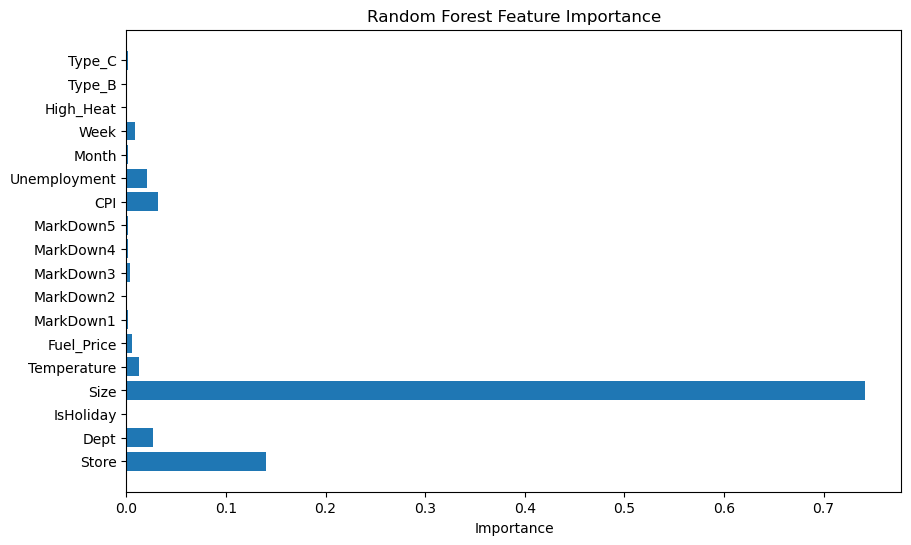

In [129]:
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.savefig("feature_importance.png", bbox_inches="tight", dpi=300)
plt.show()

## Feature Importance Interpretation

Feature importance analysis shows that Store Size is by far the dominant predictor of weekly sales.

Other variables contribute marginally in comparison. This indicates that overall sales levels are primarily driven by structural store capacity rather than short-term external factors.

While seasonal variables such as Week are included in the model, their relative importance is significantly lower than Store Size, suggesting that structural scale differences across stores explain much of the variation in sales.

### Limitations and Challenges

While the model performs very well, we encountered some limitations:

1. **Data challenges:**  
   - Categorical variables (e.g., `Type`) required one-hot encoding  
   - Missing values in Markdown columns had to be filled  

2. **Model limitations:**  
   - Random Forest is less interpretable than simpler models  
   - May not capture sudden spikes due to promotions or holidays  
   - External factors (weather, supply chain issues, competitor actions) are not included  

Despite these, the model provides reliable predictions for **inventory optimization and food waste reduction**.

### Business Insight

By accurately forecasting weekly sales:

- Stores can stock **just enough perishable items**  
- Reduce overstock and spoilage  
- Support sustainability initiatives  
- Improve profitability by minimizing unnecessary waste

This predictive model directly supports the capstone objective: **optimizing perishable inventory to reduce retail food waste**.

## Environmental Factor: High_Heat Impact

The 'High_Heat' variable was introduced to capture potential weather-related demand or spoilage risk for perishable goods.

However, feature importance analysis indicates that extreme temperature does not significantly influence total weekly sales volume in the selected departments. This suggests that while heat may affect spoilage risk operationally, it does not substantially alter overall demand levels.

This finding highlights an important distinction: environmental conditions may influence inventory management decisions, but structural factors (such as store size) and recurring seasonal patterns are the primary drivers of weekly sales.

None of the tested environmental factors significantly drive total weekly demand. Sales spikes are primarily seasonal rather than weather-driven.

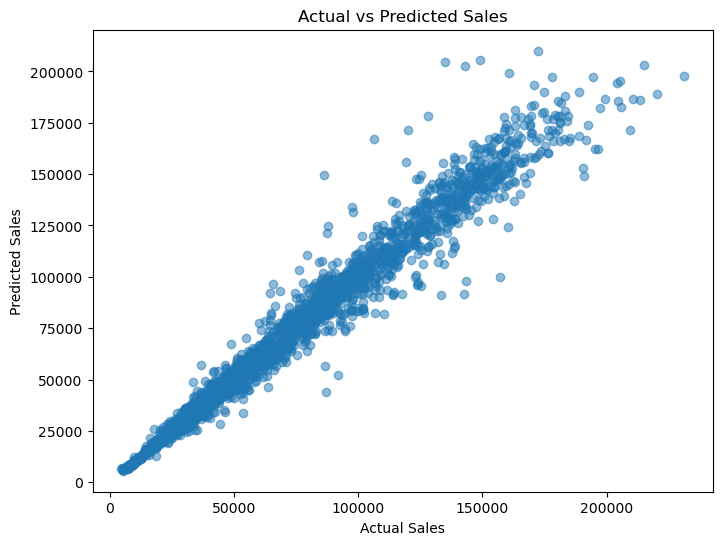

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.savefig("actual_vs_predicted.png", bbox_inches="tight", dpi=300)
plt.show()

## Actual vs Predicted Comparison

The scatter plot above compares actual weekly sales with model predictions.

Most data points cluster closely around the diagonal pattern, indicating strong predictive alignment. While some deviation exists particularly at extreme sales values the overall distribution confirms the model’s robustness.

This visual validation supports the quantitative metrics (MAE and R²), demonstrating that the Random Forest model reliably captures sales patterns.

In [137]:
import os
os.getcwd()

'C:\\Users\\user'